In [14]:
import warnings
warnings.filterwarnings("ignore")

In [15]:
from pydantic import BaseModel, Field
from typing import List, TypedDict, Literal

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
load_dotenv()


True

In [16]:
docs = ( PyPDFLoader('./Company_Profile.pdf').load()
        + PyPDFLoader('./Company_Policies.pdf').load()
        + PyPDFLoader('./Product_and_Pricing.pdf').load())

In [17]:
#Chunking,Embeddings Generation,Store in FAISS,Retriever

chunks = RecursiveCharacterTextSplitter(chunk_size=600,chunk_overlap=150).split_documents(docs)
Embedding_model = OpenAIEmbeddings(model='text-embedding-3-large')
Vector_Store = FAISS.from_documents(chunks,Embedding_model)
retriever = Vector_Store.as_retriever(search_kwargs={'k':4})

In [18]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


In [19]:
# state graph

class State(TypedDict):
    question: str
    need_retrieval: bool
    retrieved_context: List[Document]
    answer: str

In [20]:
# Decide Retrieval Node

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


class Retrieval_decision(BaseModel):
    Need_retrieval:bool= Field(...,
    description="True if external documents are needed to answer the question, otherwise False")
    
llm_with_structured_output = llm.with_structured_output(Retrieval_decision)

def decide_retrieval(state:State) -> bool:

    retrieval_decision = llm_with_structured_output.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
        )
    return {"need_retrieval": retrieval_decision.Need_retrieval}

In [21]:
# generate Direct Answer Node (for questions that don't need retrieval)

direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct_answer(state:State):

    answer = llm.invoke(direct_generation_prompt.format_messages(question=state["question"])).content
    return {"answer": answer}

In [22]:
# retrieve node
def retrieve(state:State):
    return {"retrieved_context": retriever.invoke(state["question"])}


# generate answer from retrieved context
retrieve_answer_prompt = ChatPromptTemplate.from_messages([
    ("system", "Answer the question using ONLY the following context. If the context doesn't contain the answer, say so.\n\nContext:\n{context}"),
    ("human", "{question}"),
])

def generate_answer_with_retrieval(state:State):
    context = "\n\n".join(doc.page_content for doc in state["retrieved_context"])
    answer = llm.invoke(retrieve_answer_prompt.format_messages(context=context, question=state["question"])).content
    return {"answer": answer}


In [23]:
def router_retrieval_check(state:State) -> Literal["retrieve","generate_direct_answer"]:
    if state["need_retrieval"]:
        return "retrieve"
    else:
        return "generate_direct_answer"   

In [24]:
graph = StateGraph(State)

graph.add_node("decide_retrieval", decide_retrieval)
graph.add_node("retrieve", retrieve)
graph.add_node("generate_direct_answer", generate_direct_answer)
graph.add_node("generate_answer_with_retrieval", generate_answer_with_retrieval)

graph.add_edge(START, "decide_retrieval")
graph.add_conditional_edges(
    "decide_retrieval",
    router_retrieval_check,
    {
        "generate_direct_answer": "generate_direct_answer",
        "retrieve": "retrieve"
    }
)

graph.add_edge("generate_direct_answer", END)
graph.add_edge("retrieve", "generate_answer_with_retrieval")
graph.add_edge("generate_answer_with_retrieval", END)

app = graph.compile()

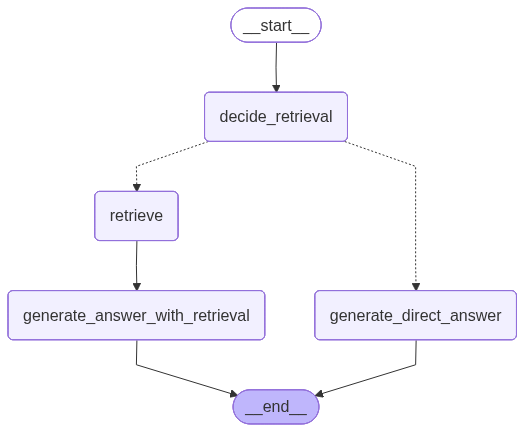

In [25]:
app

In [26]:
result = app.invoke(
    {
        "question": "What is Machine Learning",
        "need_retrieval": False,
        "retrieved_context": [],
        "answer": "",
    }
)

print(result["answer"])


Machine learning is a subset of artificial intelligence (AI) that focuses on the development of algorithms and statistical models that enable computers to perform tasks without explicit programming. Instead of being programmed with specific instructions, machine learning systems learn from data, identifying patterns and making decisions based on that data.

There are several types of machine learning, including:

1. **Supervised Learning**: The model is trained on labeled data, meaning the input data is paired with the correct output. The goal is to learn a mapping from inputs to outputs.

2. **Unsupervised Learning**: The model is trained on data without labeled responses. It seeks to identify patterns or groupings within the data.

3. **Semi-Supervised Learning**: This approach combines both labeled and unlabeled data to improve learning accuracy.

4. **Reinforcement Learning**: The model learns by interacting with an environment and receiving feedback in the form of rewards or penal